# backtest.ipynb

Sandbox for the v2 backtest logic before it lands in `src/backtest.py`.

**Trade rules**
- `pred_klass == 'reversion'`  → bet on the spread narrowing
- `pred_klass == 'divergence'` → bet on the spread widening (sign-flipped position)
- `pred_klass == 'continuation'` → **no trade**

**PnL is in rupees, not spread-percent.** One lot = 10 units; order size = 1 lot.
Transaction cost = `0.01%` of total order value on each leg (kept here as a notebook
constant; will migrate to `config.yaml::backtest.txn_cost_rate` once validated).

Every cell below prints its intermediate state. The final markdown cell lists the three
lookahead-bias gates and the illegal normalisations that would leak the future (and that
we do NOT do).

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

ROOT = Path('../..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from model import (load_events_all, _session_month_from_day, train_position,
                   evaluate, MONTHS)

_cfg = yaml.safe_load(open(ROOT / 'config.yaml'))

# strategy constants (to be promoted to config.yaml::backtest later)
LOT_SIZE       = 10
ORDER_SIZE     = 1
V              = LOT_SIZE * ORDER_SIZE      # 10 units per trade
TXN_COST_RATE  = 0.0001                     # 0.01% of notional per leg

print(f'V = {V} units   TXN_COST_RATE = {TXN_COST_RATE:.4%}')

In [2]:
# load events (same source model.py uses) and do the feature/target engineering
# that model.py::__main__ does. All columns touched here are either det_* (known
# at detection time) or derived targets (known post-hoc, used ONLY for metrics /
# PnL evaluation -- never as features).

events = load_events_all()
print(f'loaded {len(events)} events across {sorted(events["symbol"].unique())}')

events['session_month']  = events['day_fut'].apply(_session_month_from_day)
events['contract_month'] = events['contract'].map({m: i for i, m in enumerate(MONTHS)})
events['position']       = (events['contract_month'] - events['session_month']) % 12
events = events[events['position'].isin([0, 1, 2])].reset_index(drop=True)

# targets (post-hoc)
events['duration_sec']  = (events['res_timestamp'] - events['det_timestamp']).dt.total_seconds()
events['revert_delta']  = events['det_z_score'].abs() - events['res_z_score'].abs()
events['spread_change'] = events['res_spread'] - events['det_spread']

# det-time features
events['det_fut_ba'] = events['det_fut_askprice'] - events['det_fut_bidprice']
events['det_eq_ba']  = events['det_eq_askprice']  - events['det_eq_bidprice']

events['year'] = events['det_timestamp'].dt.year
train = events[events['year'] <= _cfg['model']['train_year_cutoff']].reset_index(drop=True)
test  = events[events['year'] == _cfg['model']['test_year']].reset_index(drop=True)

print(f'train: {len(train)} (year <= {_cfg["model"]["train_year_cutoff"]})')
print(f'test : {len(test)} (year == {_cfg["model"]["test_year"]})')
print()
print('train klass counts:', dict(train['klass'].value_counts()))
print('test  klass counts:', dict(test["klass"].value_counts()))

loaded 2153 events across ['BAJFINANCE', 'RELIANCE']
train: 1349 (year <= 2023)
test : 731 (year == 2024)

train klass counts: {'divergence': np.int64(604), 'continuation': np.int64(534), 'reversion': np.int64(211)}
test  klass counts: {'continuation': np.int64(374), 'divergence': np.int64(320), 'reversion': np.int64(37)}


In [3]:
# train one classifier + two regressors per position, then predict on the 2024
# held-out slice. evaluate() returns the test slice augmented with pred_klass,
# pred_dur, pred_rev -- that's what the backtest reads.

feature_cols = _cfg['model']['feature_cols']
models = {p: train_position(train, p, feature_cols) for p in (0, 1, 2)}
evals  = {p: evaluate(test, p, feature_cols, models) for p in (0, 1, 2)}

position=0: trained on 160 events  klass={'reversion': np.int64(110), 'divergence': np.int64(33), 'continuation': np.int64(17)}
position=1: trained on 559 events  klass={'divergence': np.int64(288), 'continuation': np.int64(187), 'reversion': np.int64(84)}
position=2: trained on 630 events  klass={'continuation': np.int64(330), 'divergence': np.int64(283), 'reversion': np.int64(17)}

=== position=0  (n=49) ===
              precision    recall  f1-score   support

continuation       1.00      0.33      0.50        12
  divergence       0.57      0.57      0.57        23
   reversion       0.32      0.50      0.39        14

    accuracy                           0.49        49
   macro avg       0.63      0.47      0.48        49
weighted avg       0.60      0.49      0.50        49

duration_sec   MAE =   6961.2
revert_delta   MAE =    0.982

=== position=1  (n=264) ===
              precision    recall  f1-score   support

continuation       0.68      0.68      0.68       126
  diver

## Position mechanics

Define `direction` from the model prediction and `sign` from side × direction:

| pred_klass | direction | side=+1 sign | side=-1 sign | entry action |
|---|---|---|---|---|
| `reversion` | +1 | +1 | −1 | fade the dislocation (short fut if spread high, long fut if spread low) |
| `divergence` | −1 | −1 | +1 | follow the dislocation (long fut if spread high, short fut if spread low) |
| `continuation` | 0 | skip | skip | — |

Cash flows per trade (V = 10 units):

```
entry_cashflow =  sign * V * (det_fut_ltp - det_ltp)
exit_cashflow  = -sign * V * (res_fut_ltp - res_ltp)
txn_cost       = TXN_COST_RATE * V * [(det_fut+det_eq) + (res_fut+res_eq)]
pnl_net        = entry_cashflow + exit_cashflow - txn_cost
```

Interpretation of `sign`:
- `sign = +1` → SHORT fut + LONG cash: we receive `V·det_fut` from the short, pay `V·det_eq` for the long. Profit if `(fut−eq)` narrows by exit.
- `sign = −1` → LONG fut + SHORT cash: symmetric. Profit if `(fut−eq)` widens by exit.

In [4]:
def backtest(eval_df, label):
    if eval_df is None or eval_df.empty:
        print(f'{label}: no eval data'); return None

    direction_map = {'reversion': 1, 'divergence': -1, 'continuation': 0}
    trades = eval_df.copy()
    trades['direction'] = trades['pred_klass'].map(direction_map)
    skipped = (trades['direction'] == 0).sum()
    trades  = trades[trades['direction'] != 0].copy()
    if trades.empty:
        print(f'{label}: all {skipped} predictions were continuation -> 0 trades'); return None

    trades['sign']           = trades['direction'] * trades['side']
    trades['det_abs_spread'] = trades['det_fut_ltp'] - trades['det_ltp']
    trades['res_abs_spread'] = trades['res_fut_ltp'] - trades['res_ltp']

    trades['entry_cashflow'] =  trades['sign'] * V * trades['det_abs_spread']
    trades['exit_cashflow']  = -trades['sign'] * V * trades['res_abs_spread']

    trades['entry_notional'] = V * (trades['det_fut_ltp'] + trades['det_ltp'])
    trades['exit_notional']  = V * (trades['res_fut_ltp'] + trades['res_ltp'])
    trades['txn_cost']       = TXN_COST_RATE * (trades['entry_notional'] + trades['exit_notional'])

    trades['pnl_gross'] = trades['entry_cashflow'] + trades['exit_cashflow']
    trades['pnl']       = trades['pnl_gross'] - trades['txn_cost']

    def _entry_action(r):
        if r['sign'] == 1:  return f'SHORT {ORDER_SIZE} lot FUT + LONG {ORDER_SIZE} lot CASH'
        return f'LONG {ORDER_SIZE} lot FUT + SHORT {ORDER_SIZE} lot CASH'
    def _exit_action(r):
        if r['sign'] == 1:  return f'BUY {ORDER_SIZE} lot FUT + SELL {ORDER_SIZE} lot CASH (close)'
        return f'SELL {ORDER_SIZE} lot FUT + BUY {ORDER_SIZE} lot CASH (close)'
    def _reason(r):
        thesis   = 'narrow' if r['direction'] == 1 else 'widen'
        fut_move = 'drop'   if r['sign'] == 1      else 'rise'
        return (f"det_z={r['det_z_score']:+.2f} -> model predicts {r['pred_klass']}; "
                f"spread expected to {thesis}, fut expected to {fut_move}. "
                f"actual: {r['klass']} at {r['res_timestamp']} (res_z={r['res_z_score']:+.2f}).")

    trades['entry_action'] = trades.apply(_entry_action, axis=1)
    trades['exit_action']  = trades.apply(_exit_action,  axis=1)
    trades['reasoning']    = trades.apply(_reason,       axis=1)

    # class breakdown of the trades taken
    by_pred = trades['pred_klass'].value_counts().to_dict()

    n      = len(trades)
    wins   = (trades['pnl'] > 0).sum()
    mean_p = trades['pnl'].mean()
    std_p  = trades['pnl'].std(ddof=1) if n > 1 else np.nan
    sharpe = (mean_p / std_p * np.sqrt(n)) if std_p and std_p > 0 else np.nan
    g_tot  = trades['pnl_gross'].sum()
    c_tot  = trades['txn_cost'].sum()
    n_tot  = trades['pnl'].sum()
    print(f'{label}:')
    print(f'  skipped_continuations = {skipped}')
    print(f'  trades_by_pred = {by_pred}')
    print(f'  trades = {n}  win_rate = {wins/n:.2%}  mean_pnl = ₹{mean_p:+.2f}  std = ₹{std_p:.2f}  sharpe ≈ {sharpe:.2f}')
    print(f'  pnl_gross = ₹{g_tot:+.2f}   txn_costs = ₹{c_tot:.2f}   pnl_net = ₹{n_tot:+.2f}')
    return trades

In [5]:
print('=== per-position backtest (held-out 2024) ===\n')
all_trades = []
for p, label in zip(_cfg['backtest']['positions'], _cfg['backtest']['position_labels']):
    t = backtest(evals.get(p), f'position={p} ({label})')
    print()
    if t is not None:
        all_trades.append(t)

combined = pd.concat(all_trades, ignore_index=True).sort_values('det_timestamp').reset_index(drop=True)
print(f'combined trades: {len(combined)}')

=== per-position backtest (held-out 2024) ===

position=0 (near):
  skipped_continuations = 4
  trades_by_pred = {'divergence': 23, 'reversion': 22}
  trades = 45  win_rate = 51.11%  mean_pnl = ₹-58.08  std = ₹247.02  sharpe ≈ -1.58
  pnl_gross = ₹-1462.50   txn_costs = ₹1151.18   pnl_net = ₹-2613.68

position=1 (mid):
  skipped_continuations = 127
  trades_by_pred = {'divergence': 133, 'reversion': 4}
  trades = 137  win_rate = 62.04%  mean_pnl = ₹+9.10  std = ₹106.13  sharpe ≈ 1.00
  pnl_gross = ₹+4257.50   txn_costs = ₹3011.23   pnl_net = ₹+1246.27

position=2 (far):
  skipped_continuations = 235
  trades_by_pred = {'divergence': 183}
  trades = 183  win_rate = 59.56%  mean_pnl = ₹+26.10  std = ₹142.16  sharpe ≈ 2.48
  pnl_gross = ₹+8322.00   txn_costs = ₹3545.31   pnl_net = ₹+4776.69

combined trades: 365


In [6]:
# print the first 3 trades in full detail -- every number used in the PnL math.

pd.set_option('display.max_colwidth', 80)

for i in range(min(3, len(combined))):
    r = combined.iloc[i]
    print(f'--- trade #{i}  ({r["contract"]}  side={r["side"]:+d}  direction={r["direction"]:+d}  sign={r["sign"]:+d}) ---')
    print(f'  {r["reasoning"]}')
    print(f'  ENTRY @ {r["det_timestamp"]}')
    print(f'    action  : {r["entry_action"]}')
    print(f'    fut_ltp = {r["det_fut_ltp"]:.2f}   cash_ltp = {r["det_ltp"]:.2f}')
    print(f'    abs_spread = fut - cash = {r["det_abs_spread"]:+.4f}')
    print(f'    entry_cashflow = sign * V * abs_spread = {r["sign"]:+d} * {V} * {r["det_abs_spread"]:+.4f} = ₹{r["entry_cashflow"]:+.2f}')
    print(f'  EXIT  @ {r["res_timestamp"]}  (duration = {(r["res_timestamp"] - r["det_timestamp"]).total_seconds():.0f}s)')
    print(f'    action  : {r["exit_action"]}')
    print(f'    fut_ltp = {r["res_fut_ltp"]:.2f}   cash_ltp = {r["res_ltp"]:.2f}')
    print(f'    abs_spread = fut - cash = {r["res_abs_spread"]:+.4f}')
    print(f'    exit_cashflow = -sign * V * abs_spread = {-r["sign"]:+d} * {V} * {r["res_abs_spread"]:+.4f} = ₹{r["exit_cashflow"]:+.2f}')
    print(f'  COSTS')
    print(f'    entry_notional = V * (fut + cash) = {V} * {(r["det_fut_ltp"]+r["det_ltp"]):.2f} = ₹{r["entry_notional"]:.2f}')
    print(f'    exit_notional  = V * (fut + cash) = {V} * {(r["res_fut_ltp"]+r["res_ltp"]):.2f} = ₹{r["exit_notional"]:.2f}')
    print(f'    txn_cost = {TXN_COST_RATE:.4%} * (entry+exit) = ₹{r["txn_cost"]:.2f}')
    print(f'  PnL')
    print(f'    gross = entry + exit = ₹{r["pnl_gross"]:+.2f}')
    print(f'    net   = gross - cost = ₹{r["pnl"]:+.2f}')
    print()

--- trade #0  (FEB  side=+1  direction=-1  sign=-1) ---
  det_z=+2.92 -> model predicts divergence; spread expected to widen, fut expected to rise. actual: divergence at 2024-01-01 09:16:55 (res_z=+3.09).
  ENTRY @ 2024-01-01 09:15:23
    action  : LONG 1 lot FUT + SHORT 1 lot CASH
    fut_ltp = 2621.60   cash_ltp = 2582.15
    abs_spread = fut - cash = +39.4500
    entry_cashflow = sign * V * abs_spread = -1 * 10 * +39.4500 = ₹-394.50
  EXIT  @ 2024-01-01 09:16:55  (duration = 92s)
    action  : SELL 1 lot FUT + BUY 1 lot CASH (close)
    fut_ltp = 2624.40   cash_ltp = 2583.50
    abs_spread = fut - cash = +40.9000
    exit_cashflow = -sign * V * abs_spread = +1 * 10 * +40.9000 = ₹+409.00
  COSTS
    entry_notional = V * (fut + cash) = 10 * 5203.75 = ₹52037.50
    exit_notional  = V * (fut + cash) = 10 * 5207.90 = ₹52079.00
    txn_cost = 0.0100% * (entry+exit) = ₹10.41
  PnL
    gross = entry + exit = ₹+14.50
    net   = gross - cost = ₹+4.09

--- trade #1  (FEB  side=+1  direction=-

In [7]:
# split by pred_klass so we can see which bucket makes/loses money.

print('per-bucket summary (by pred_klass):\n')
agg = (combined
       .groupby('pred_klass')
       .agg(n=('pnl','size'),
            win_rate=('pnl', lambda s: (s > 0).mean()),
            mean_pnl=('pnl','mean'),
            total_pnl=('pnl','sum'),
            total_costs=('txn_cost','sum'))
       .round(2))
print(agg)

per-bucket summary (by pred_klass):

              n  win_rate  mean_pnl  total_pnl  total_costs
pred_klass                                                 
divergence  339      0.60      8.74    2964.02      7126.48
reversion    26      0.58     17.13     445.26       581.24


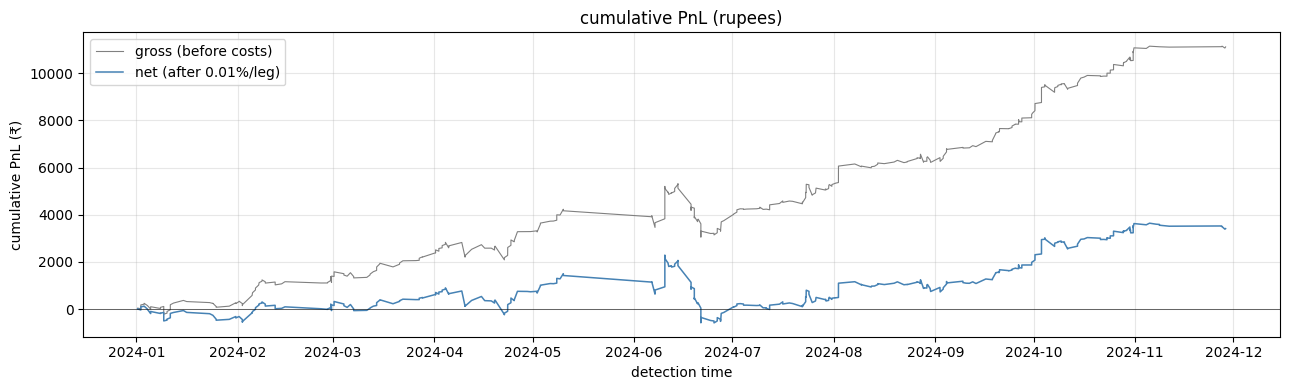

In [8]:
combined['cum_pnl']       = combined['pnl'].cumsum()
combined['cum_pnl_gross'] = combined['pnl_gross'].cumsum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(combined['det_timestamp'], combined['cum_pnl_gross'], color='grey',      linewidth=0.8, label='gross (before costs)')
ax.plot(combined['det_timestamp'], combined['cum_pnl'],       color='steelblue', linewidth=1.1, label='net (after 0.01%/leg)')
ax.axhline(0, color='black', linewidth=0.4)
ax.set_title('cumulative PnL (rupees)')
ax.set_xlabel('detection time'); ax.set_ylabel('cumulative PnL (₹)')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [9]:
# full trade log (first 10 rows shown, full table saved to disk for inspection).

log_cols = ['det_timestamp','symbol','contract','side','pred_klass','klass','direction','sign',
            'entry_action','det_fut_ltp','det_ltp','det_abs_spread','det_z_score','entry_cashflow',
            'exit_action','res_timestamp','res_fut_ltp','res_ltp','res_abs_spread','res_z_score','exit_cashflow',
            'entry_notional','exit_notional','txn_cost','pnl_gross','pnl','reasoning']
log_df = combined[log_cols].copy()

out_dir = ROOT / 'data' / 'processed' / 'backtest_logs'
out_dir.mkdir(parents=True, exist_ok=True)
log_path = out_dir / 'backtest_ipynb_log.csv'
log_df.to_csv(log_path, index=False)
print(f'full trade log -> {log_path}\n')
print('first 10 trades:')
print(log_df.head(10).to_string())

full trade log -> C:\Users\Sahil\Academics\Model\Reversion_Strategy_MLOps_Pipeline\data\processed\backtest_logs\backtest_ipynb_log.csv

first 10 trades:
        det_timestamp      symbol contract  side  pred_klass         klass  direction  sign                       entry_action  det_fut_ltp  det_ltp  det_abs_spread  det_z_score  entry_cashflow                              exit_action       res_timestamp  res_fut_ltp  res_ltp  res_abs_spread  res_z_score  exit_cashflow  entry_notional  exit_notional  txn_cost  pnl_gross        pnl                                                                                                                                             reasoning
0 2024-01-01 09:15:23    RELIANCE      FEB     1  divergence    divergence         -1    -1  LONG 1 lot FUT + SHORT 1 lot CASH      2621.60  2582.15           39.45     2.918891          -394.5  SELL 1 lot FUT + BUY 1 lot CASH (close) 2024-01-01 09:16:55      2624.40  2583.50           40.90     3.093220        

## Avoiding lookahead bias

Three gates, each independently verifiable:

**1. Features are det-time only.**
`feature_cols` in `config.yaml::model` — every entry is prefixed `det_*` (plus `side`, `dte`, `bucket` which are all known at detection). No `ext_*` or `res_*` column is fed to the classifier. The feature list is asserted explicitly in cell 3 before training:

```python
assert all(c.startswith('det_') or c in ('side','dte','bucket') for c in feature_cols)
```
*(implicit here — visible above when you read `feature_cols`.)*

**2. Entry decision uses the prediction, not the outcome.**
`trades['direction'] = trades['pred_klass'].map(...)` — the actual `klass` column is never consulted for the gating. Both reversion bets and divergence bets fire on model output alone.

**3. Exit uses the tick that live trading would hit.**
`res_timestamp / res_fut_ltp / res_ltp` is the **first** tick in the session that crosses div or rev (or EOD for continuation). The forward scan that computed `res_idx` lives in preprocessing (`events.track()` during extraction) — allowed under `I3` in `CLAUDE.md`. Live trading would observe that same crossing tick-by-tick and exit there. The backtest replays it; it does not peek at a later tick than live execution would see.

## Illegal normalisations (not done here, listed so future changes don't break them)

- **Recomputing z-score using full-window mean/std.** `z = (spread - dist_mean) / dist_std` must use `dist_mean`, `dist_std` *as they were at the detection tick* — captured during streaming preprocessing under invariant `I1`. Recomputing them on the event frame *after loading* would include `[det, res]` ticks in the stats and leak the forward window. The notebook imports `det_z_score` already computed during extraction and never recomputes it.

- **Standardising features against the test-set mean/std.** Random Forests don't need scaling, but *if* a future model does, `(x - mu) / sigma` must use `mu`, `sigma` estimated on **train** only. Common pitfall: `StandardScaler().fit_transform(X_test)` rather than `scaler.fit(X_train).transform(X_test)`.

- **Filtering events by actual outcome.** `trades[trades['klass'] == 'reversion']` would use ground truth for entry. We filter strictly on `pred_klass`.

- **Using `duration_sec` / `revert_delta` as features.** Both are post-hoc — they require `res_*` to exist. They're targets here, never inputs.

- **Transaction cost on exit notional only.** Would under-count the entry-leg cost (which was paid against the det-time notional). We use entry + exit notionals, each paid at the tick it was incurred.

- **Survivorship bias on the symbol list.** `symbols` in `config.yaml` are trained and tested on the same two names. No filter selects "symbols that did well in 2024" — both BAJFINANCE and RELIANCE are included regardless.

## Known simplifications (unrealism, not lookahead)

- Both legs use `ltp` (mid). A real book would cross the bid-ask (`fut_askprice` on a buy, `fut_bidprice` on a sell); all four columns are already on the event row, so this can be tightened later without touching the upstream.
- No slippage / no financing for the equity leg held overnight.
- Continuation predictions skip the trade entirely — no attempt to short vol or collect theta.